In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros de la simulación
N_BATERIAS = 10000
CAPACIDAD_MEDIA = 3000   # mAh
CAPACIDAD_STD = 120      # mAh
UMBRAL_FIN_VIDA = 0.80   # 80% de la capacidad inicial

# Degradaciones medias por ciclo (convertidas a proporción, ej: 0.03% -> 0.0003)
DEG_20C = 0.0003
DEG_35C = 0.0005
DEG_45C = 0.0008

# Probabilidades de cada temperatura
PROBS = [0.50, 0.35, 0.15]
DEGS = [DEG_20C, DEG_35C, DEG_45C]

# Máximo estimado de ciclos para evitar bucles infinitos en la vectorización
# (A la menor tasa de degradación 0.03%, tardaría unos 743 ciclos en llegar al 80%)
MAX_CICLOS = 1500

In [ ]:
# Fijamos una semilla aleatoria para que los resultados sean reproducibles
np.random.seed(42)

# 1. Simular la capacidad inicial de las 10.000 baterías
capacidad_inicial = np.random.normal(CAPACIDAD_MEDIA, CAPACIDAD_STD, N_BATERIAS)

# 2. Asignar temperatura aleatoria y aplicar degradación para cada día
temperaturas = np.random.choice(DEGS, size=(N_BATERIAS, MAX_CICLOS), p=PROBS)
capacidad_porcentual = np.cumprod(1 - temperaturas, axis=1)

# 3. Calcular el número total de ciclos hasta alcanzar el umbral del 80%
baterias_debajo_umbral = capacidad_porcentual < UMBRAL_FIN_VIDA
ciclos_vida = np.argmax(baterias_debajo_umbral, axis=1) + 1 # +1 porque el índice 0 es el ciclo 1

In [3]:
# 4. Obtener las estadísticas solicitadas
vida_media = np.mean(ciclos_vida)
desviacion_estandar = np.std(ciclos_vida)
prob_mas_1000 = np.mean(ciclos_vida > 1000)

print("-" * 40)
print("RESULTADOS DE LA SIMULACIÓN DE MONTECARLO")
print("-" * 40)
print(f"Número de baterías simuladas : {N_BATERIAS}")
print(f"Vida media                   : {vida_media:.2f} ciclos")
print(f"Desviación estándar          : {desviacion_estandar:.2f} ciclos")
print(f"Prob. de durar > 1000 ciclos : {prob_mas_1000:.4%} ({prob_mas_1000})")
print(f"Ciclos máximos alcanzados    : {np.max(ciclos_vida)}")
print(f"Ciclos mínimos alcanzados    : {np.min(ciclos_vida)}")
print("-" * 40)

----------------------------------------
RESULTADOS DE LA SIMULACIÓN DE MONTECARLO
----------------------------------------
Número de baterías simuladas : 10000
Vida media                   : 501.77 ciclos
Desviación estándar          : 8.77 ciclos
Prob. de durar > 1000 ciclos : 0.0000% (0.0)
Ciclos máximos alcanzados    : 532
Ciclos mínimos alcanzados    : 469
----------------------------------------


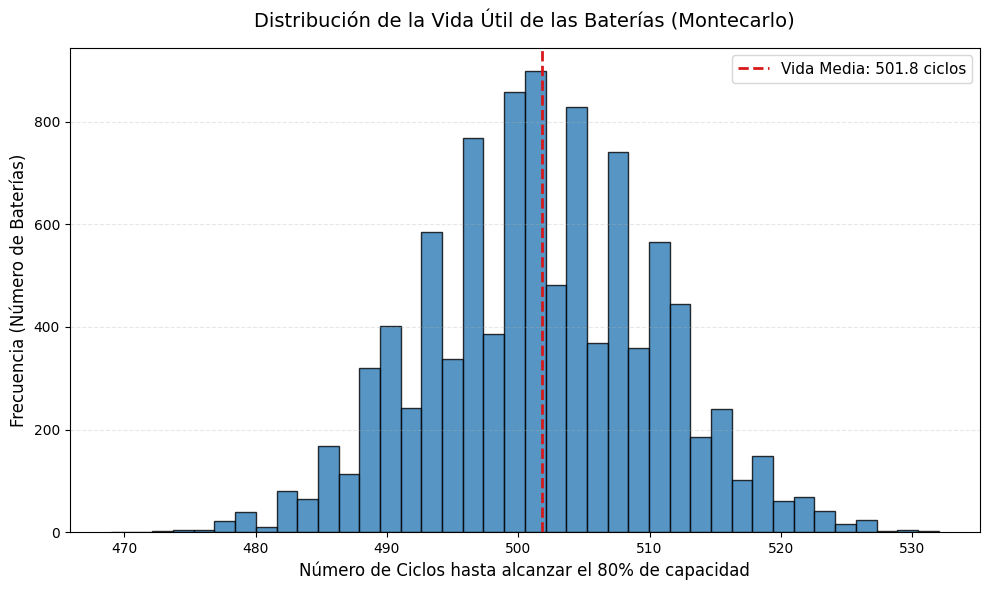

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(ciclos_vida, bins=40, color='#2c7bb6', edgecolor='black', alpha=0.8)
plt.axvline(vida_media, color='#d7191c', linestyle='dashed', linewidth=2, 
            label=f'Vida Media: {vida_media:.1f} ciclos')
plt.title('Distribución de la Vida Útil de las Baterías (Montecarlo)', fontsize=14, pad=15)
plt.xlabel('Número de Ciclos hasta alcanzar el 80% de capacidad', fontsize=12)
plt.ylabel('Frecuencia (Número de Baterías)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()